In [60]:
# Import libraries and load the CSV
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [61]:
# Load your dataset
df = pd.read_csv("Review_Page (1).csv")

# Show first five rows
df.head()

,Review_id,Rating,Review_text
0,1,1,Worst food experience..... I ordered home styl...
1,2,1,"worst food, thay use shahi paneer gravy in ra..."
2,3,1,I don t feel like giving a single star They do...
3,4,1,Very bad and late service. We gone for dinner ...
4,5,1,Very bad servicing late order having issue Of ...


In [62]:
# Inspect and clean the data

# Check column names and data types
df.info()

# Count missing values
print(df.isnull().sum())

# Remove rows with no rating or no review text
df = df.dropna(subset=["Rating", "Review_text"])

# Remove duplicate reviews
df = df.drop_duplicates(subset=["Review_text"])

# Ensure Rating is a number
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Keep only ratings from 1 to 5
df = df[df["Rating"].between(1, 5)]

# Convert review text to string
df["Review_text"] = df["Review_text"].astype(str)

print("Number of reviews after cleaning:", len(df))
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Review_id    61 non-null     int64
 1   Rating       61 non-null     int64
 2   Review_text  61 non-null     str  
dtypes: int64(2), str(1)
memory usage: 1.6 KB
Review_id      0
Rating         0
Review_text    0
dtype: int64
Number of reviews after cleaning: 61


,Review_id,Rating,Review_text
0,1,1,Worst food experience..... I ordered home styl...
1,2,1,"worst food, thay use shahi paneer gravy in ra..."
2,3,1,I don t feel like giving a single star They do...
3,4,1,Very bad and late service. We gone for dinner ...
4,5,1,Very bad servicing late order having issue Of ...


In [63]:
# Clean the review text

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # Remove links
    text = re.sub(r"[^a-z\s]", "", text)      # Remove punctuation and numbers
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    return text

df["Clean_review"] = df["Review_text"].apply(clean_text)

df[["Review_text", "Clean_review"]].head()

,Review_text,Clean_review
0,Worst food experience..... I ordered home styl...,worst food experience i ordered home style chi...
1,"worst food, thay use shahi paneer gravy in ra...",worst food thay use shahi paneer gravy in rara...
2,I don t feel like giving a single star They do...,i don t feel like giving a single star they do...
3,Very bad and late service. We gone for dinner ...,very bad and late service we gone for dinner o...
4,Very bad servicing late order having issue Of ...,very bad servicing late order having issue of ...


In [64]:
# Create sentiment labels

def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Can be improved"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(create_sentiment)

# Check how many reviews belong to each group
print(df["Sentiment"].value_counts())

df[["Review_text", "Rating", "Sentiment"]].head(60)

Sentiment
Positive           31
Negative           25
Can be improved     5
Name: count, dtype: int64


,Review_text,Rating,Sentiment
0,Worst food experience..... I ordered home styl...,1,Negative
1,"worst food, thay use shahi paneer gravy in ra...",1,Negative
2,I don t feel like giving a single star They do...,1,Negative
3,Very bad and late service. We gone for dinner ...,1,Negative
4,Very bad servicing late order having issue Of ...,1,Negative
5,I am inform you that your F and B staff servic...,1,Negative
6,Extremely disappointing experience. We were le...,1,Negative
7,"The quality of the food is good, but the staff...",1,Negative
8,Once i order biryani from this place and there...,1,Negative
9,Service is very poor i have ordered my food bu...,1,Negative


In [65]:
df.to_csv("cleaned_restaurant_reviews.csv", index=False)

In [66]:
# EDA: basic analysis and charts

In [67]:
# Average rating
print("Average restaurant rating:", round(df["Rating"].mean(), 2))
print("Median restaurant rating:", df["Rating"].median())

Average restaurant rating: 3.1
Median restaurant rating: 4.0


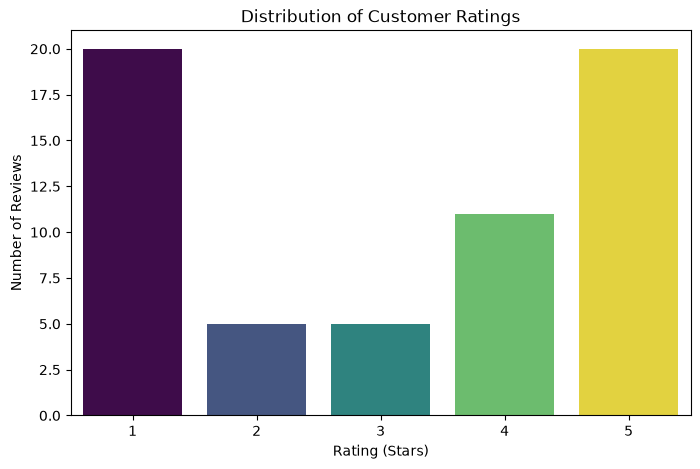

In [68]:
# Rating distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Rating", hue="Rating", palette="viridis", legend=False)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Reviews")
plt.show()

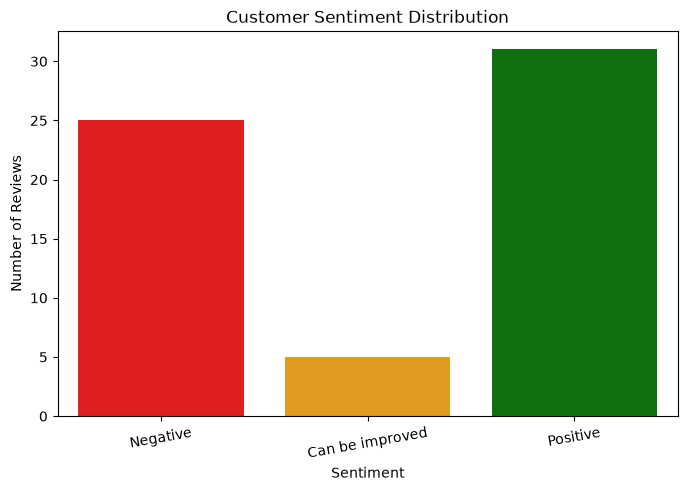

In [69]:
# Sentiment distribution

plt.figure(figsize=(8, 5))

order = ["Negative", "Can be improved", "Positive"]

sns.countplot(
    data=df,
    x="Sentiment",
    order=order,
    hue="Sentiment",
    palette=["red", "orange", "green"],
    legend=False
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=10)
plt.show()

In [70]:
# Percentage of each sentiment

sentiment_percentage = df["Sentiment"].value_counts(normalize=True) * 100
print(sentiment_percentage.round(2))

Sentiment
Positive           50.82
Negative           40.98
Can be improved     8.20
Name: proportion, dtype: float64


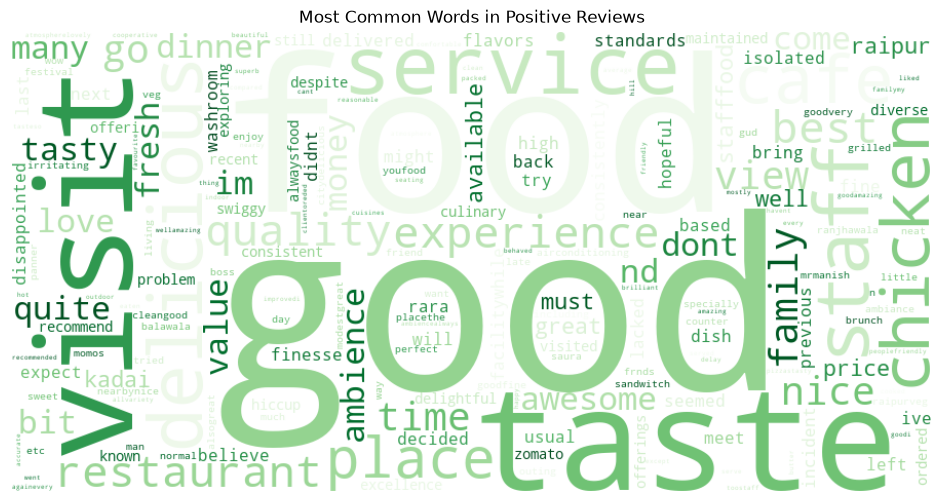

In [71]:
# Word clouds
#Positive reviews

positive_text = "".join(
    df[df["Sentiment"] == "Positive"]["Clean_review"]
)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Reviews")
plt.show()

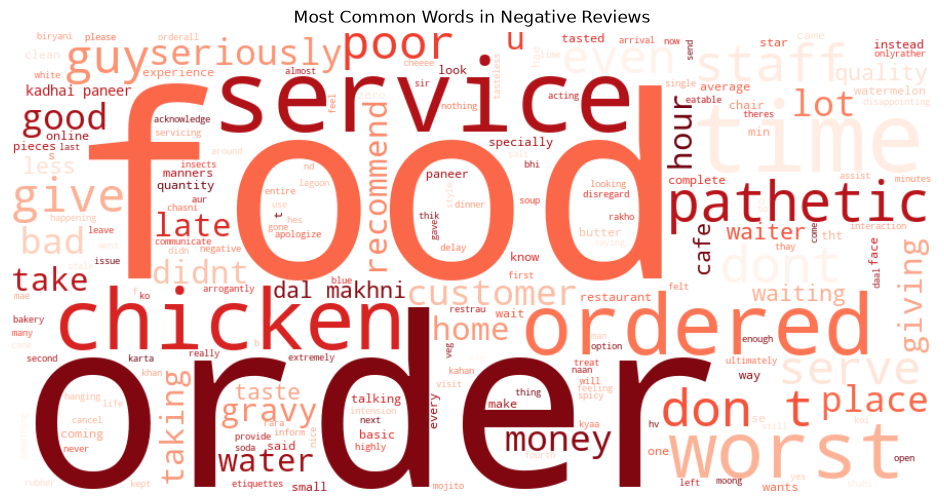

In [72]:
# Negative reviews
negative_text = " ".join(
    df[df["Sentiment"] == "Negative"]["Clean_review"]
)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()

In [73]:
# Analyze restaurant topics
# This checks whether reviews mention food, service, price, ambience, or waiting time.
topics = {
    "Food": ["food", "taste", "Quality", "chicken","paneer", "meal", "gravy", "pizza", "biryani"],
    "Service": ["service", "staff", "waiter", "behavior","owner"],
    "Price": ["price", "expensive", "cheap", "cost", "value", "money"],
    "Ambience": ["ambience", "atmosphere", "environment", "clean", "cleanliness","view"],
    "Waiting time": ["slow", "waiting", "wait", "delay", "late","hour","minutes"]
}

for topic, keywords in topics.items():
    pattern = "|".join(keywords)
    df[topic] = df["Clean_review"].str.contains(pattern, case=False, na=False)

topic_counts = {topic: df[topic].sum() for topic in topics}
topic_df = pd.DataFrame(
    list(topic_counts.items()),
    columns=["Topic", "Number_of_reviews"]
).sort_values("Number_of_reviews", ascending=False)

print(topic_df)

          Topic  Number_of_reviews
0          Food                 51
1       Service                 31
4  Waiting time                 14
3      Ambience                 12
2         Price                  9


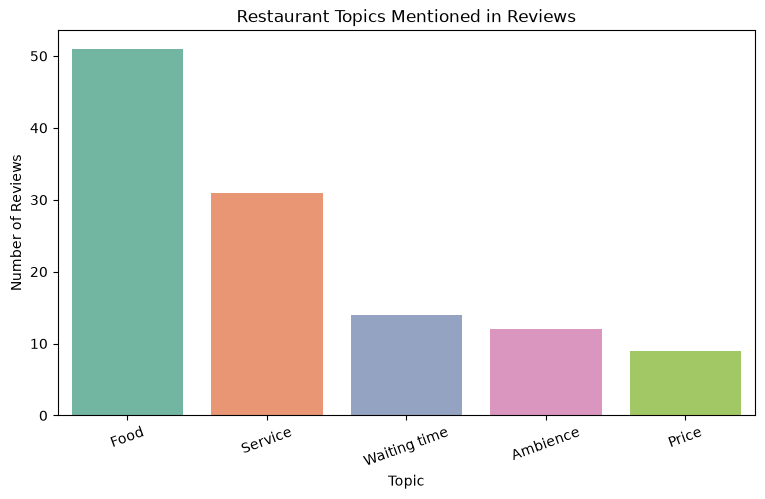

In [74]:
plt.figure(figsize=(9, 5))
sns.barplot(data=topic_df, x="Topic", y="Number_of_reviews", hue="Topic", palette="Set2", legend=False)

plt.title("Restaurant Topics Mentioned in Reviews")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=20)
plt.show()

In [75]:
 # Hypothesis testing
# Business question:
# Do reviews mentioning “service” have lower ratings than reviews that do not mention service?

service_ratings = df[df["Service"]]["Rating"]
no_service_ratings = df[~df["Service"]]["Rating"]

print("Average rating when service is mentioned:", round(service_ratings.mean(), 2))
print("Average rating when service is not mentioned:", round(no_service_ratings.mean(), 2))

t_statistic, p_value = ttest_ind(
    service_ratings,
    no_service_ratings,
    equal_var=False,
    nan_policy="omit"
)

print("T-statistic:", round(t_statistic, 3))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion: There is statistically significant evidence that service-related reviews have a different average rating.")
else:
    print("Conclusion: There is not enough statistical evidence of a rating difference in this small dataset.")

Average rating when service is mentioned: 2.94
Average rating when service is not mentioned: 3.27
T-statistic: -0.753
P-value: 0.4547
Conclusion: There is not enough statistical evidence of a rating difference in this small dataset.


In [76]:
# Machine-learning sentiment model
# This model learns from review text and predicts:
# Negative, Can be improved, or Positive.
X = df["Clean_review"]
y = df["Sentiment"]

# Check the number of reviews in each sentiment category
print(y.value_counts())

Sentiment
Positive           31
Negative           25
Can be improved     5
Name: count, dtype: int64


In [77]:
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Build TF-IDF + Logistic Regression pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Train model
model.fit(X_train, y_train)

# Predict test reviews
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 84.62 %

Classification report:

                 precision    recall  f1-score   support

Can be improved       0.00      0.00      0.00         1
       Negative       1.00      0.80      0.89         5
       Positive       0.78      1.00      0.88         7

       accuracy                           0.85        13
      macro avg       0.59      0.60      0.59        13
   weighted avg       0.80      0.85      0.81        13



c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

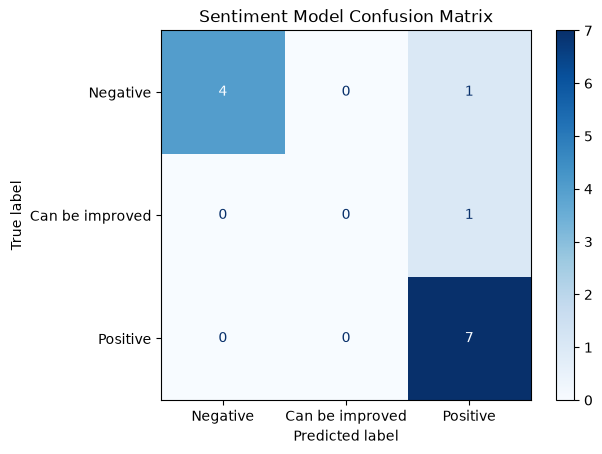

In [78]:
#  Confusion matrix

labels = ["Negative", "Can be improved", "Positive"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

display.plot(cmap="Blues")
plt.title("Sentiment Model Confusion Matrix")
plt.show()

In [79]:
# Test the model with a new review

new_review = [
    "The food was tasty but the service was very slow."
]

prediction = model.predict(new_review)

print("Predicted sentiment:", prediction[0])

Predicted sentiment: Negative
